In [36]:
import glob
import os
import time
import importlib
from scipy import ndimage

import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

import numpy as np

import h5py  
import sys
from scipy.ndimage import gaussian_filter

In [37]:
import os
os.getcwd()

'/home/oyf2/Week 4'

In [38]:
import multiprocessing as mp
print(mp.cpu_count())

96


In [39]:
from xtec.Preprocessing import Mask_Zeros              # to remove zero intensity points from data       
from xtec.Preprocessing import Threshold_Background    # for thresholding background intensity

from sklearn.cluster import AgglomerativeClustering   # for AGNES clustering

In [40]:
#search_dir = '/nfs/chess/id4baux/2024-1/postec-3946-a/nxrefine/Ag8GeS6/AGS1/'
search_dir = "/nfs/chess/id4baux/2025-2/he-4025-d/nxrefine/Ta2NiSeS70/S1/"   # the dir containing the numbered folders
Tlist = [17, 21, 25, 30, 35, 40, 50, 60, 70, 90, 110, 115, 117, 119, 121, 123, 126, 129, 140, 150, 160, 170, 180, 240]

In [41]:
#search_dir = '/nfs/chess/id4baux/2024-1/postec-3946-a/nxrefine/Ag8GeS6/AGS1/'
#search_dir = "/nfs/chess/id4baux/2024-1/wilson-3947-a/nxrefine/CsV3Sb5Snx/ACS5-11-1/"
#arr = os.listdir(search_dir)
#print(search_dir)

#dir_arr = []
#T_dir_dict = {}
#for item in arr:
   # if not item.endswith('.nxs'):
  #      dir_arr.append(search_dir+item+'/transform.nxs')
    #    T_dir_dict[item] = search_dir+item+'/transform.nxs'
        
#print(T_dir_dict)  
#print(T_dir_dict.keys())
#Tlist = list(T_dir_dict.keys())
#print(Tlist)


In [42]:
#arr = os.listdir('/nfs/chess/id4baux/2024-1/postec-3946-a/nxrefine/Ag8GeS6/AGS1/')
#arr = os.listdir('/nfs/chess/id4baux/2024-1/wilson-3947-a/nxrefine/CsV3Sb5Snx/ACS5-11-1/')

#print(arr)

In [43]:
Tnames = []
for T in Tlist:
    Tsplit = str(T).split('.')
    if len(Tsplit) > 1:
        Tnames.append(Tsplit[0] + 'p' + Tsplit[1])
    else:
        Tnames.append(Tsplit[0])

filepaths = [search_dir + T + '/transform.nxs' for T in Tnames]  # subdir layout
print(filepaths)

# transform.nxs holds the intensity volume (entry/data/v)
datapaths = [search_dir + T + '/transform.nxs' for T in Tnames]
# the flat per-T files hold the Q axes at entry/transform/Qh|Qk|Ql
axispaths = [search_dir + 'Ta2NiSeS70_' + T + '.nxs' for T in Tnames]
filepaths = datapaths   # keep this name for the rest of the notebook
print(datapaths[0])
print(axispaths[0])

['/nfs/chess/id4baux/2025-2/he-4025-d/nxrefine/Ta2NiSeS70/S1/17/transform.nxs', '/nfs/chess/id4baux/2025-2/he-4025-d/nxrefine/Ta2NiSeS70/S1/21/transform.nxs', '/nfs/chess/id4baux/2025-2/he-4025-d/nxrefine/Ta2NiSeS70/S1/25/transform.nxs', '/nfs/chess/id4baux/2025-2/he-4025-d/nxrefine/Ta2NiSeS70/S1/30/transform.nxs', '/nfs/chess/id4baux/2025-2/he-4025-d/nxrefine/Ta2NiSeS70/S1/35/transform.nxs', '/nfs/chess/id4baux/2025-2/he-4025-d/nxrefine/Ta2NiSeS70/S1/40/transform.nxs', '/nfs/chess/id4baux/2025-2/he-4025-d/nxrefine/Ta2NiSeS70/S1/50/transform.nxs', '/nfs/chess/id4baux/2025-2/he-4025-d/nxrefine/Ta2NiSeS70/S1/60/transform.nxs', '/nfs/chess/id4baux/2025-2/he-4025-d/nxrefine/Ta2NiSeS70/S1/70/transform.nxs', '/nfs/chess/id4baux/2025-2/he-4025-d/nxrefine/Ta2NiSeS70/S1/90/transform.nxs', '/nfs/chess/id4baux/2025-2/he-4025-d/nxrefine/Ta2NiSeS70/S1/110/transform.nxs', '/nfs/chess/id4baux/2025-2/he-4025-d/nxrefine/Ta2NiSeS70/S1/115/transform.nxs', '/nfs/chess/id4baux/2025-2/he-4025-d/nxrefine/Ta2

In [44]:
doc = h5py.File(filepaths[0], 'r')
print(doc)
print(doc['entry/data/v'].shape)
doc.close()

<HDF5 file "transform.nxs" (mode r)>
(1191, 1721, 1221)


In [45]:
doc = h5py.File(axispaths[0], 'r')
Qh = np.array(doc['entry/transform']['Qh'])
Qk = np.array(doc['entry/transform']['Qk'])
Ql = np.array(doc['entry/transform']['Ql'])
doc.close()

delta_Qh = Qh[1] - Qh[0]
delta_Qk = Qk[1] - Qk[0]
delta_Ql = Ql[1] - Ql[0]

print(Qh.shape, Qk.shape, Ql.shape)
print('Ql=', Ql[0], ' to ', Ql[-1], np.round(delta_Ql, 3))
print('Qk=', Qk[0], ' to ', Qk[-1], np.round(delta_Qk, 3))
print('Qh=', Qh[0], ' to ', Qh[-1], np.round(delta_Qh, 3))

(1221,) (1721,) (1191,)
Ql= -23.8  to  23.8 0.04
Qk= -21.5  to  21.5 0.025
Qh= -6.1  to  6.1 0.01


In [46]:
x=abs(Qh-np.round(Qh))-0.5*delta_Qh
H_Bragg_ind=np.where(x<0)[0]

x=abs(Qk-np.round(Qk))-0.5*delta_Qk
K_Bragg_ind=np.where(x<0)[0]


x=abs(Ql-np.round(Ql))-0.5*delta_Ql
L_Bragg_ind=np.where(x<0)[0]


Qh_Bragg=Qh[H_Bragg_ind]
Qk_Bragg=Qk[K_Bragg_ind]
Ql_Bragg=Ql[L_Bragg_ind]

print('Qh Bragg', np.round(Qh_Bragg,3))
print('Qk Bragg', np.round(Qk_Bragg,3))
print('Ql_Bragg', np.round(Ql_Bragg,3))


cell_start_ind=[(p,q,r)  for p in L_Bragg_ind[0:-1] for q in K_Bragg_ind[0:-1] for r in H_Bragg_ind[0:-1]] 

cell_size=(int(L_Bragg_ind[1]-L_Bragg_ind[0]),int(K_Bragg_ind[1]-K_Bragg_ind[0]),int(H_Bragg_ind[1]-H_Bragg_ind[0]))
print('unit cell size (#L,#K,#H)=', cell_size)

num_cells=len(cell_start_ind)
print('num of cells=', num_cells )

Qh Bragg [-6. -5. -4. -3. -2. -1.  0.  1.  2.  3.  4.  5.  6.]
Qk Bragg [-21. -20. -19. -18. -17. -16. -15. -14. -13. -12. -11. -10.  -9.  -8.
  -7.  -6.  -5.  -4.  -3.  -2.  -1.   0.   1.   2.   3.   4.   5.   6.
   7.   8.   9.  10.  11.  12.  13.  14.  15.  16.  17.  18.  19.  20.
  21.]
Ql_Bragg [-23. -22. -21. -20. -19. -18. -17. -16. -15. -14. -13. -12. -11. -10.
  -9.  -8.  -7.  -6.  -5.  -4.  -3.  -2.  -1.   0.   1.   2.   3.   4.
   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.  15.  16.  17.  18.
  19.  20.  21.  22.  23.]
unit cell size (#L,#K,#H)= (25, 40, 100)
num of cells= 23184


In [47]:
sig=(0,0.0,0.0,0.0)#(T,H,K,L) no smooting
#sig=(0,0.5,0.5,0.5)#(T,H,K,L)

In [48]:
def Extract_smooth_unit_cell_data(sig, cpu_counter):
    
    data_slice={}
    smooth_window= (int(4*sig[1]), int(4*sig[2]), int(4*sig[3]))     

    
    unit_start=cell_start_ind[cpu_counter]

    if (((unit_start[0]+cell_size[0])>=len(Ql)) or 
        ((unit_start[1]+cell_size[1])>=len(Qk)) or 
        ((unit_start[2]+cell_size[2])>=len(Qh))):
            print('wrong cell shape')
            return None
    
    
    
    #get min and max indices of enlarged cell 
    l_min=max(0,unit_start[0]-smooth_window[0])
    k_min=max(0,unit_start[1]-smooth_window[1])
    h_min=max(0,unit_start[2]-smooth_window[2])

    l_max=min(len(Ql)-1,unit_start[0]+cell_size[0]+smooth_window[0])
    k_max=min(len(Qk)-1,unit_start[1]+cell_size[1]+smooth_window[1])
    h_max=min(len(Qh)-1,unit_start[2]+cell_size[2]+smooth_window[2])

    
    
    Qh_cell=Qh[h_min:h_max]
    Qk_cell=Qk[k_min:k_max]
    Ql_cell=Ql[l_min:l_max]



    # read data from this cell
    data = []
    num_T=len(filepaths)
    for filepath in filepaths:
        doc = h5py.File(filepath, 'r')
        dataT = doc['entry/data/v'][l_min:l_max, k_min:k_max, h_min:h_max]        
        data.append(dataT)
        doc.close()
    I = np.squeeze(data)   
    
    if (np.amax(I)  < 1):
        return data_slice  # skip empty slices
    
    I= gaussian_filter(I,sig)

    #get min and max indices unit cell inside this enlarged cell 
    l_min=max(0,smooth_window[0])
    k_min=max(0,smooth_window[1])
    h_min=max(0,smooth_window[2])

    l_max=min(I.shape[1],cell_size[0]+smooth_window[0])
    k_max=min(I.shape[2],cell_size[1]+smooth_window[1])
    h_max=min(I.shape[3],cell_size[2]+smooth_window[2])

    
    
    Qh_cell=Qh_cell[h_min:h_max]
    Qk_cell=Qk_cell[k_min:k_max]
    Ql_cell=Ql_cell[l_min:l_max]
    
    # clip down I to the unit cell
    I=I[:,l_min:l_max,k_min:k_max,h_min:h_max]
    
    try:
        masked    = Mask_Zeros(I)
        threshold = Threshold_Background(masked)
        num_thresholded  = threshold.data_thresholded.shape[1]
        if num_thresholded  == 0:
            return data_slice
    except:
        return data_slice   # if thresholding failed for this unit cell
    
    
    
    
    max_num_features = 5000
    sector_id=int(cpu_counter)*max_num_features
    
    structure_element = np.ones((3,3,3))    # to identify features if they are connected, even diagonally
    labeled_array, num_features = ndimage.label(threshold.thresholded,structure=structure_element)
                    # threshold.thresholded :  non_zero data(h,k,l)=1 if above cutoff 
                    # labelled_array(h,k,l) has connected features (#num_features) marked by different integers 
    labels= list(range(1,num_features+1))
    
    if(num_features>max_num_features):
        print('num features too large', num_features,max_num_features)
        return 
    
    
    # remove Bragg peaks
    
    #finding Bragg labels
    Bragg_inds = [(i,j,k) for i in [0,cell_size[0]-1] for j in [0,cell_size[1]-1] for k in [0,cell_size[2]-1]]
    Bragg_labels = [labeled_array[ind] for ind in Bragg_inds]   # labels at Brag_loc
    Bragg_labels = np.unique(Bragg_labels)

    # non bragg labels
    Non_Bragg_labels=np.setdiff1d(labels,Bragg_labels+[0])
    Non_Bragg_labels = np.unique(Non_Bragg_labels)

    NonBragg_mask = np.isin(labeled_array,Non_Bragg_labels)           # returns true for labeled arrays that match  NonBragg_labels
    NonBragg_ind  = np.array(np.where(NonBragg_mask)).transpose()    # h,k,l indices of non Bragg data, (#non_Bragg_data, 3) 
    
    # number of non bragg peaks
    num_NB= len(Non_Bragg_labels)
    # now for each peak (connected set of pixels) find peak avg, max, tot, and indices of pixels in the peak
    peak_avg = np.zeros((num_NB,num_T))       # peak averaged non bragg int, shape=(num_T, num_NB)
    peak_tot = np.zeros((num_NB,num_T))
    peak_max = np.zeros((num_NB,num_T))
    
    ind_in_peak={} #the hkl indices of all pixels in a peak 
    data_in_peak={} # intensity data of all pixels in a peak
     
    peak_label = np.zeros(num_NB) # labels of peak averaged non bragg intensities
    peak_COM   = np.zeros([num_NB,num_T,3])
    
    
    
    
        
    
    count=0
    for nbl in Non_Bragg_labels:
        mask_i  = np.isin(labeled_array,nbl)
        
        data_i  = I[:,mask_i]
        
        peak_tot[count,:] = np.sum(data_i, axis=1)   
        peak_avg[count,:] = np.mean(data_i, axis=1)  
        peak_max[count,:] = np.amax(data_i, axis=1)  
        
        
        peak_id = nbl+sector_id
        peak_label[count]   = peak_id      # label of the jth averaged Non Bragg data point, same as NonBragg_labels
        
        
        data_in_peak[peak_id]=data_i
        ind_i   = np.nonzero(mask_i)
        ind_in_peak[peak_id] = [ind_i[x]+unit_start[x] for x in [0,1,2]]
        
        
        
        for t in range(num_T):
            com=ndimage.center_of_mass(I[t]+0.001, labeled_array,nbl)
            l_com=(com[0]+unit_start[0])*(Ql[1]-Ql[0])+Ql[0]
            k_com=(com[1]+unit_start[1])*(Qk[1]-Qk[0])+Qk[0]
            h_com=(com[2]+unit_start[2])*(Qh[1]-Qh[0])+Qh[0]
            peak_COM[count,t,:]=np.array([l_com,k_com,h_com])
     
        count+=1

    data_slice['peak_avg'] = peak_avg
    data_slice['peak_tot'] = peak_tot
    data_slice['peak_max'] = peak_max
    
    data_slice['ind_in_peak']=ind_in_peak
    data_slice['data_in_peak']=data_in_peak
    
    
    data_slice['peak_label'] = peak_label
    
    data_slice['peak_COM']=peak_COM
    
    print('Completed', cpu_counter)
    return data_slice

In [49]:
import time
t = time.time()
out = Extract_smooth_unit_cell_data(sig, 0)
print('one cell took', round(time.time()-t, 2), 's')
print('keys:', None if out is None else list(out.keys()))

one cell took 0.03 s
keys: []


In [50]:
import multiprocessing as mp
from functools import partial

In [51]:
pip install multiprocess

You should consider upgrading via the '/nfs/chess/sw/qm2_XTEC/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [52]:
# prototype: process 200 cells from the middle of the list
mid = num_cells // 2
cell_subset = list(range(mid, mid + 200))
cpu_counter = cell_subset

n_cpus= 3
start_time = time.time()
import multiprocess as mp
#import multiprocessing as mp
from functools import partial   # partial functions like: func(x,y,z), par=partial(func,2,3) gives par(1)= func(2,3,1)  

Preprocessing = partial(Extract_smooth_unit_cell_data,sig)
print('num of cpus', n_cpus)
#pool = mp.Pool(mp.cpu_count())
pool = mp.Pool(n_cpus) # Leave a couple prcs free
processed_data = pool.map(Preprocessing,cpu_counter)
run_time = time.time() - start_time
print("Total Run Time:",run_time)

num of cpus 3
Completed 11606
Completed 11618
Completed 11607
Completed 11626
Completed 11627
Completed 11608
Completed 11619
Completed 11629
Completed 11620
Completed 11630
Completed 11621
Completed 11622
Completed 11643
Completed 11631
Completed 11623
Completed 11644
Completed 11624
Completed 11632
Completed 11625
Completed 11633
Completed 11645
CompletedCompleted 11634
 11646
Completed 11635
Completed 11660
Completed 11647
Completed 11636
Completed 11648
Completed 11661
Completed 11637
Completed 11638
Completed 11649
Completed 11639
Completed 11662
Completed 11650
Completed 11641
Completed 11651
Completed 11663
Completed 11642
Completed 11665
Completed 11653
Completed 11677
Completed 11678
Completed 11666
Completed 11654
Completed 11679
Completed 11655
Completed 11667
Completed 11680
Completed 11681
Completed 11668
Completed 11682Completed
 11656
Completed 11657
Completed 11669
Completed 11683
Completed 11670
Completed 11684
Completed 11658
Completed 11659
Completed 11685
Completed 

In [53]:
import pickle
pickle.dump(processed_data, open("Ta2NiSeS70_S1_CWD_sig0.p", "wb"))

In [54]:
import pickle
processed_data = pickle.load(open("Ta2NiSeS70_S1_CWD_sig0.p", "rb"))

In [55]:

peak_avg_list = []
peak_tot_list = []
peak_max_list = []
peak_COM_list = []
peak_label_list = []

ind_in_peak={}
data_in_peak={}

for num, slices in enumerate(processed_data):
    if(bool(slices)):
        peak_avg_list.append(slices['peak_avg'])
        peak_tot_list.append(slices['peak_tot'])
        peak_max_list.append(slices['peak_max'])
        peak_COM_list.append(slices['peak_COM'])
        peak_label_list.append(slices['peak_label'])
        
        ind_in_peak.update(slices['ind_in_peak'])
        data_in_peak.update(slices['data_in_peak'])
        
        
peak_avg = np.vstack(peak_avg_list)  #(num_T, num_NB_data)
peak_tot = np.vstack(peak_tot_list)  #(num_T, num_NB_data)
peak_max = np.vstack(peak_max_list)  #(num_T, num_NB_data)
peak_COM = np.vstack(peak_COM_list)  #(num_T, num_NB_data)
peak_label=np.hstack(peak_label_list)


print(peak_avg.shape)
print(peak_tot.shape)
print(peak_max.shape)
print(peak_COM.shape)
print(peak_label.shape)

print(len(ind_in_peak))
print(len(data_in_peak))

(26533, 24)
(26533, 24)
(26533, 24)
(26533, 24, 3)
(26533,)
26533
26533


In [56]:
XTEC_D_data=[]
XTEC_D_ind=[]
for i in peak_label:
    XTEC_D_data.append(data_in_peak[i])
    XTEC_D_ind.append(ind_in_peak[i])

XTEC_D_data=np.hstack(XTEC_D_data)
XTEC_D_ind=np.hstack(XTEC_D_ind)

print(XTEC_D_data.shape)
print(XTEC_D_ind.shape)

(24, 56711)
(3, 56711)


In [57]:
x_train = np.array(Tlist)
data_post_thresh = (XTEC_D_data)
data_post_thresh_no_mean = (data_post_thresh-np.mean(data_post_thresh,axis=0))/(0.01+np.std(data_post_thresh,axis=0))
X=data_post_thresh_no_mean.transpose() 

print('Data shape',X.shape)

Data shape (56711, 24)


In [58]:
n_clusters=4

In [59]:
print("Type of X:", type(X))
print("Shape of X before clustering:", X.shape)

Type of X: <class 'numpy.ndarray'>
Shape of X before clustering: (56711, 24)


In [60]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering

# 1. Take a representative sample (e.g., every 5th pixel) to fit into memory
# 56,705 / 5 = ~11,341 points, which your RAM can easily handle!
step = 5
X_sampled = np.array(X[::step])

# 2. Fit the Agglomerative Clustering on the manageable sample dataset
agg_sample = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward').fit(X_sampled)

# 3. Use a Nearest Neighbor shortcut to map the labels back to ALL 56,705 pixels
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_sampled, agg_sample.labels_)

# Create a mock object so the rest of your notebook thinks the whole thing was fitted
class MockAgg:
    def __init__(self, labels):
        self.labels_ = labels

# Predict labels for all 56,705 points and save it to 'agg'
full_labels = knn.predict(np.array(X))
agg = MockAgg(full_labels)

print("Agglomerative Clustering successfully finished via smart sampling!")

Agglomerative Clustering successfully finished via smart sampling!


In [61]:
import pickle
pickle.dump({'agg': agg}, open("Ta2NiSeS70_S1_gm.p", "wb"))

In [62]:
import numpy as np

# 1. Pull the group labels assigned by Agglomerative Clustering
cluster_assigns = agg.labels_

# 2. Re-verify the number of clusters found
n_clusters = len(np.unique(cluster_assigns))

# 3. Manually calculate the means and variances for each group
n_features = X.shape[1]
cluster_means = np.zeros((n_clusters, n_features))
cluster_covs = np.zeros((n_clusters, n_features))

for i in range(n_clusters):
    cluster_data = X[cluster_assigns == i]
    if len(cluster_data) > 0:
        cluster_means[i] = np.mean(cluster_data, axis=0)
        cluster_covs[i] = np.var(cluster_data, axis=0)

print(f"Agglomerative Clustering successfully split the data into {n_clusters} clusters!")
print("Cluster means shape:", cluster_means.shape)

Agglomerative Clustering successfully split the data into 4 clusters!
Cluster means shape: (4, 24)


In [63]:
color_list = ['firebrick', 'teal', 'gainsboro', 'purple', 'yellow', 'orange', 'pink', 'black', 'grey', 'cyan']

#marker_list=['o','s', '+']
#line_list=['-','--', ':']
#lw_list=[2,2,2]

marker_list=['o','s','p', '+']
line_list=['-','--','-.', ':']
lw_list=[2,2,2,2]

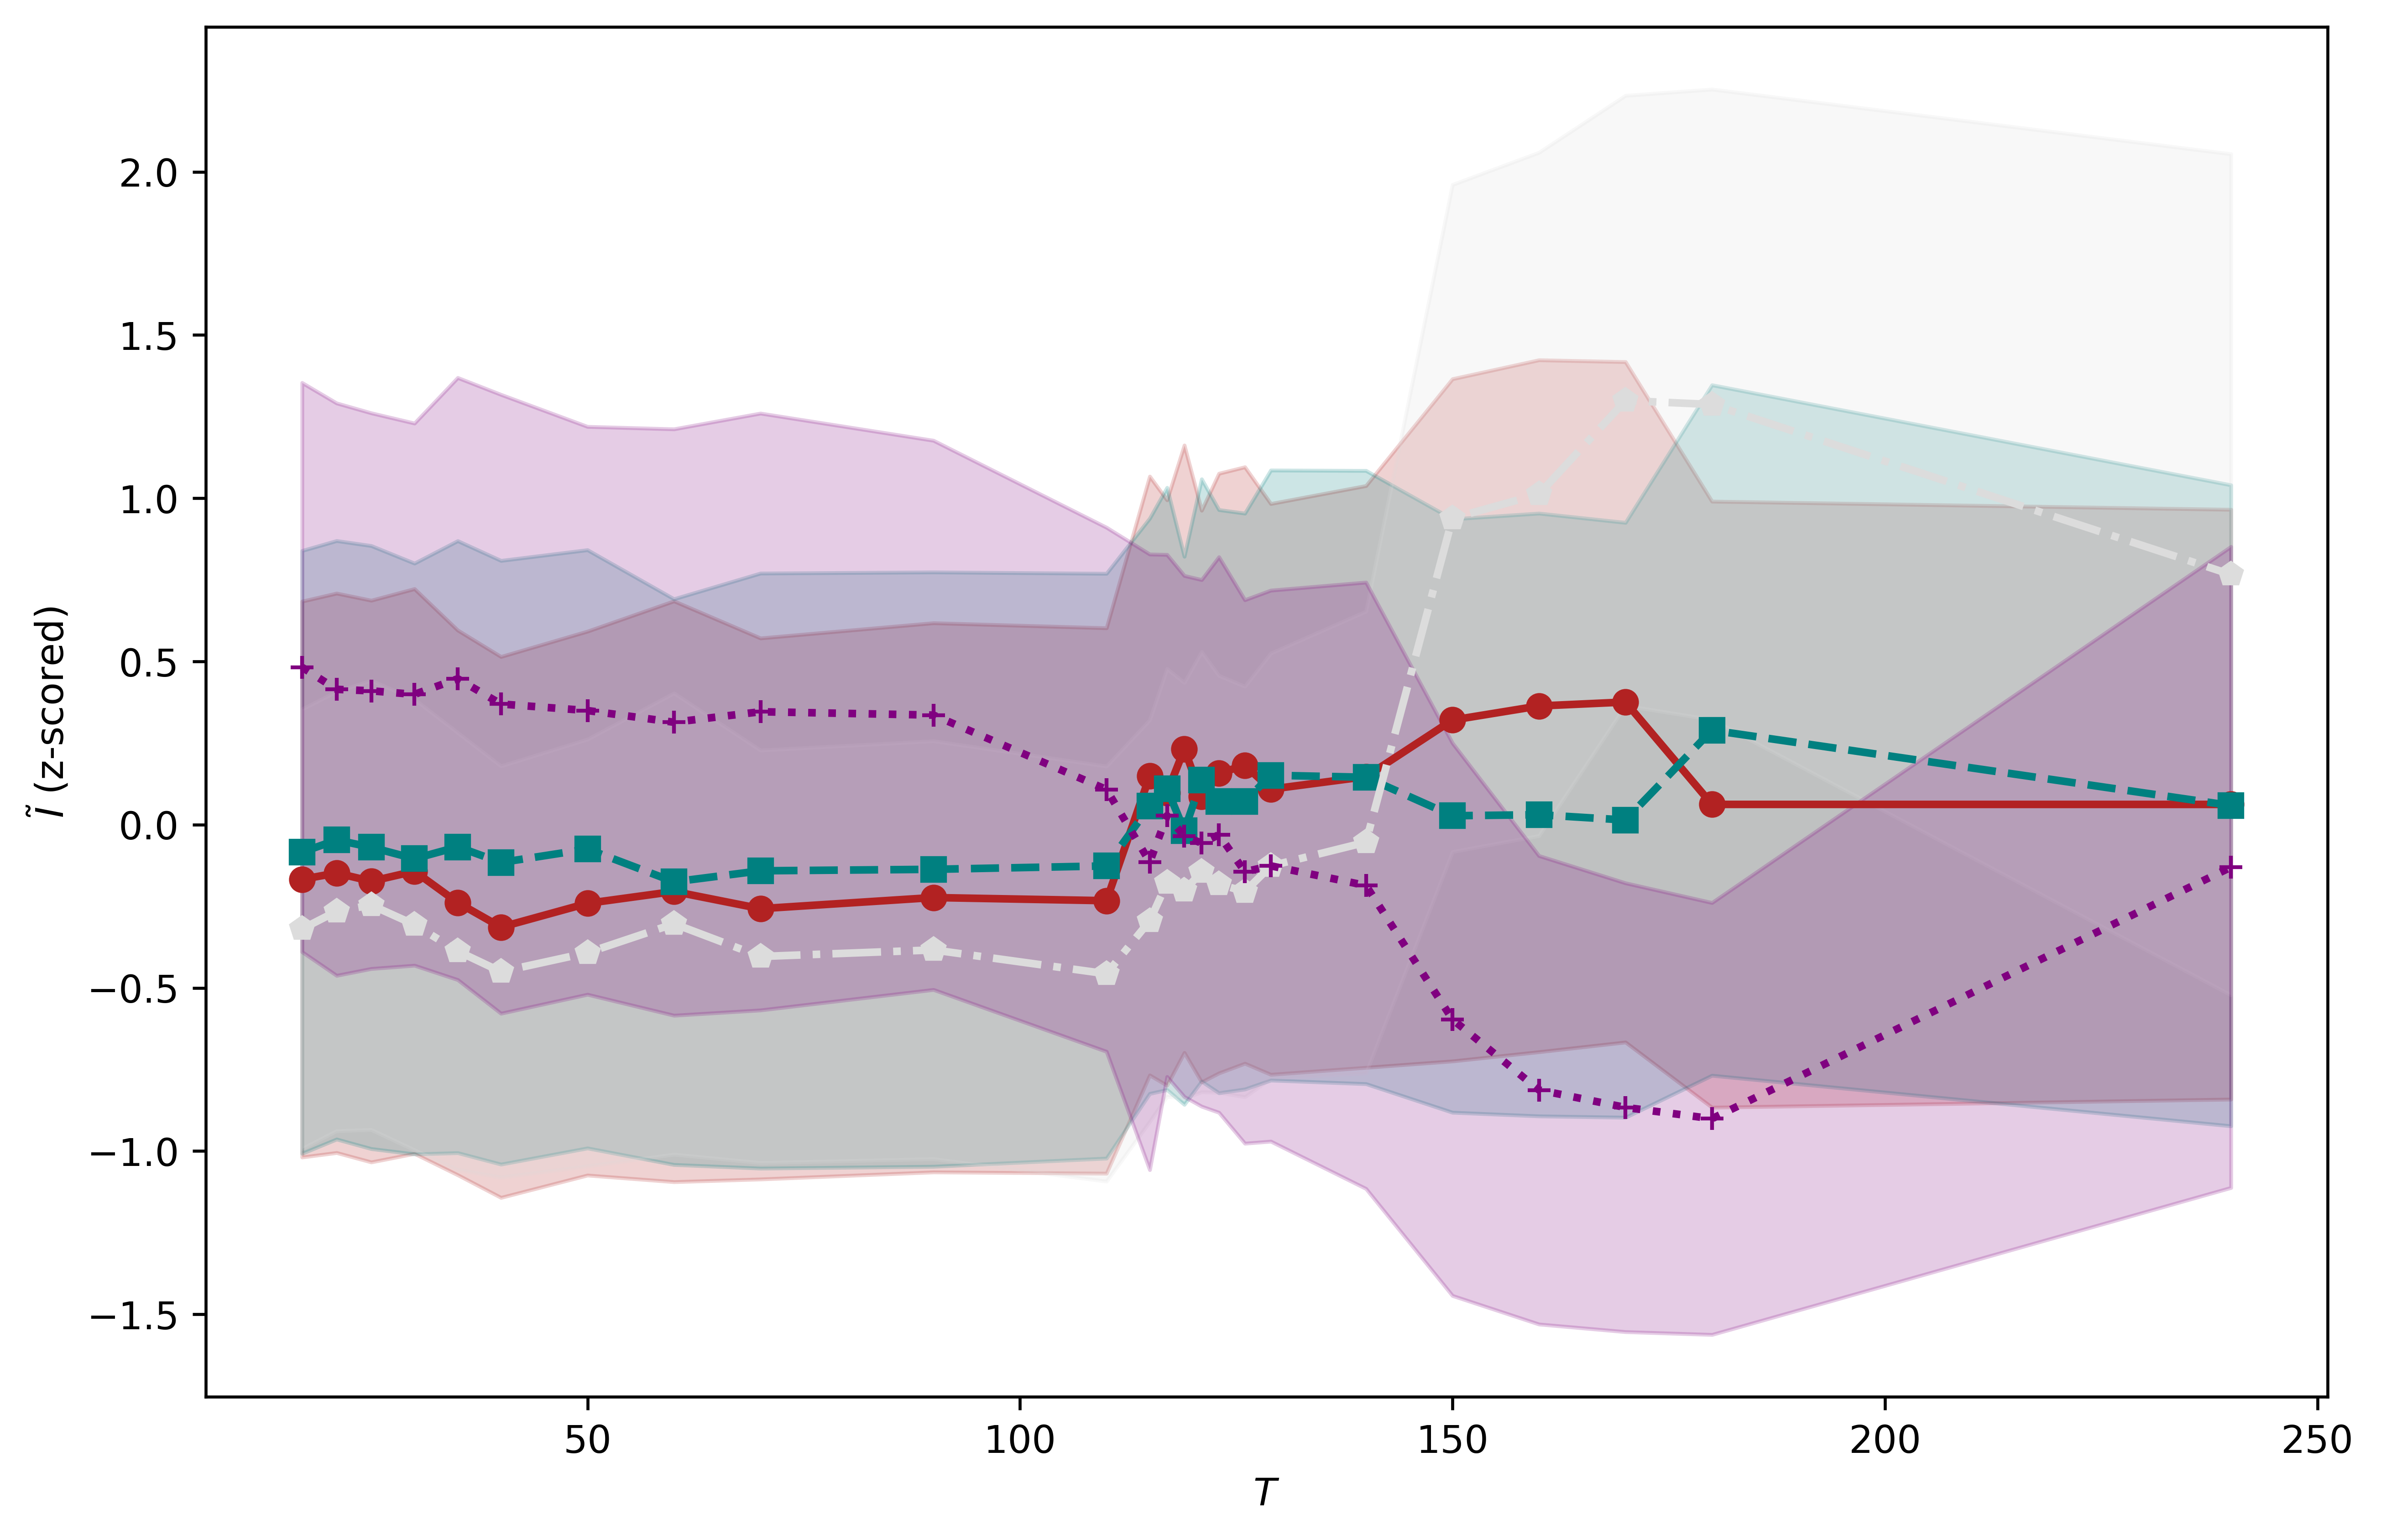

In [64]:
import matplotlib.pyplot as plt
import numpy as np # <--- Make sure this is imported

plt.figure(figsize=(10,6.5),dpi=600)
ax = plt.gca()

cluster_mean=[]
cluster_std=[]

# === PASTE THE SORTING LINES HERE ===
T_arr = np.array(Tlist)
sort_idx = np.argsort(T_arr)
Tlist_sorted = T_arr[sort_idx]
# ====================================

for i in (range(n_clusters)):
    # Add [sort_idx] to the end of these two lines to sort the data with the temperatures
    yc=cluster_means[i][sort_idx]
    yc_std=(cluster_covs[i])[sort_idx]**0.5
    
    # Change Tlist to Tlist_sorted here
    plt.plot(Tlist_sorted,yc,color=color_list[i], linestyle=line_list[i],marker=marker_list[i],lw=lw_list[i]);
    plt.gca().fill_between(Tlist_sorted,yc-yc_std,yc+ yc_std, color=color_list[i],alpha=0.2)
    
    cluster_mean.append(yc)    
    cluster_std.append(yc_std)

plt.xlabel(f'$T$',size=10)
plt.ylabel(r'$\tilde{I}$ (z-scored)',size=10)

plt.xticks(size=10);
plt.yticks(size=10);

plt.savefig('Ta2NiSeS70_S1_cluster.jpg')
plt.savefig('Ta2NiSeS70_S1_cluster.pdf')

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_Q_hist(ax_id):
    
    KDE_list=[True]*10
    if ax_id==0 :
        Q_ax=Ql
        
    if ax_id==1 :
        Q_ax=Qk
    if ax_id==2 :
        Q_ax=Qh
        #KDE_list=[True,False,True]
        

    

    for i in range(n_clusters):
        cluster_mask_i = (cluster_assigns == i)
    
        yc=XTEC_D_ind[ax_id,cluster_mask_i]
        
        yc=Q_ax[yc]
        yc=yc-np.floor(yc)
        
        plt.figure()
        #sns.distplot(yc,  kde=True,norm_hist=True, color=color_list[i], kde_kws={'linewidth': 4})
        
        
        sns.histplot(data=yc, stat='probability',bins=40, kde=KDE_list[i],edgecolor=None, color=color_list[i],line_kws={'linewidth': 3})
    
        plt.yscale("linear")
        if ax_id==2:
            L_BZ[i]=yc
            plt.xlabel('H (reduced zone)',size=20)
        if ax_id==1:
            K_BZ[i]=yc
            plt.xlabel('K (reduced zone)',size=20)
        if ax_id==0:
            H_BZ[i]=yc
            plt.xlabel('L (reduced zone)',size=20)
        
        
        
        plt.ylabel('Pixel density',size=20)
        plt.xlim([0,1])
        plt.xticks([0,0.33,0.5,0.67,1],size=18)
        plt.ylim([0,0.15])
        plt.yticks(size=0)
    
        ax=plt.gca()
        ax.yaxis.grid(False) # Hide the horizontal gridlines
        ax.xaxis.grid(True)
        ax.yaxis.set_major_locator(MultipleLocator(0.2))

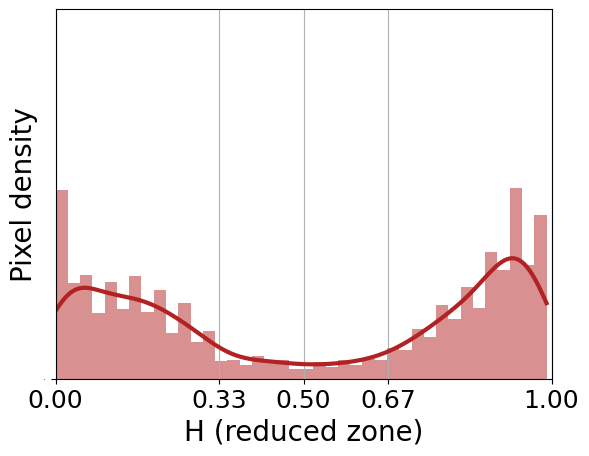

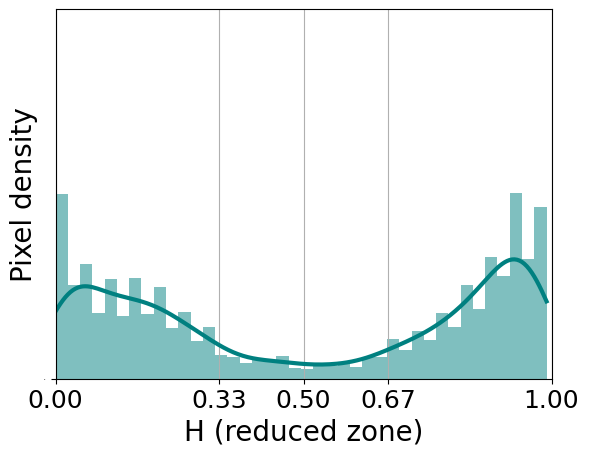

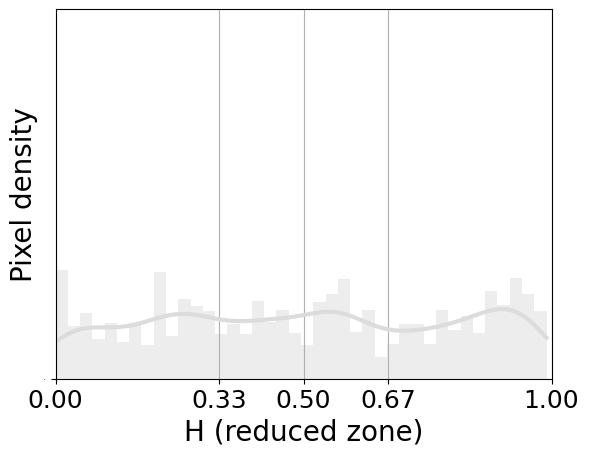

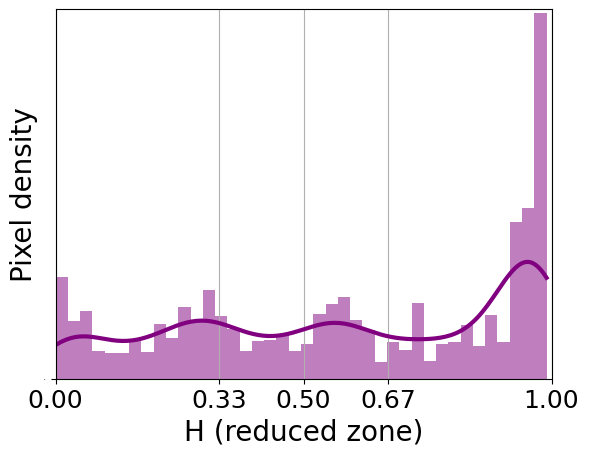

In [66]:
L_BZ={}
plot_Q_hist(2)
plt.savefig('Ta2NiSeS70_S1_cluster_L_BZ_3.jpg')
plt.savefig('Ta2NiSeS70_S1_cluster_L_BZ_3.pdf')


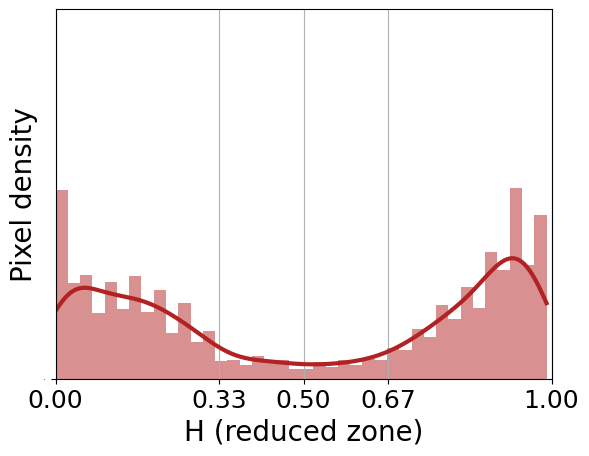

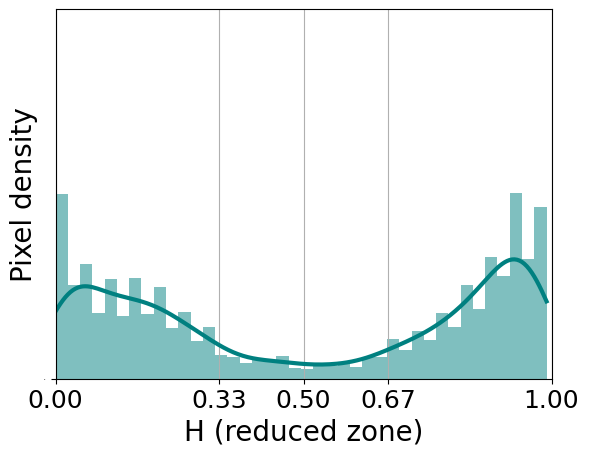

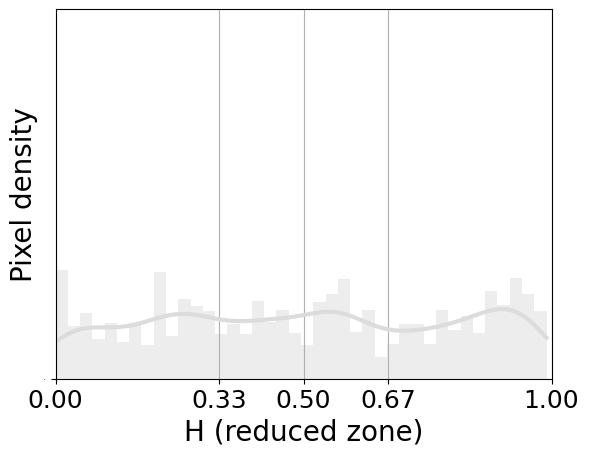

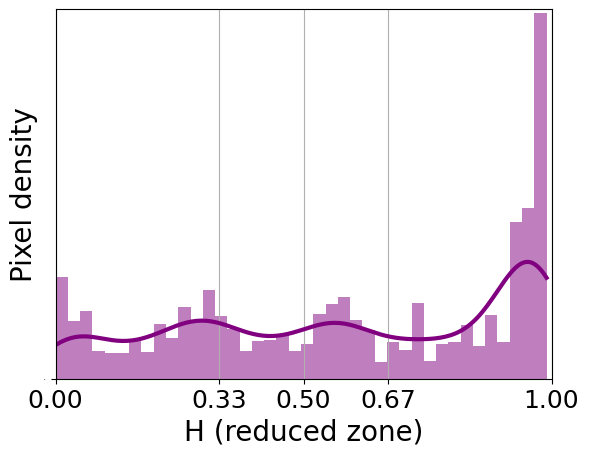

In [67]:
K_BZ={}
plot_Q_hist(2)
#plt.savefig('K_BZ_3.png')

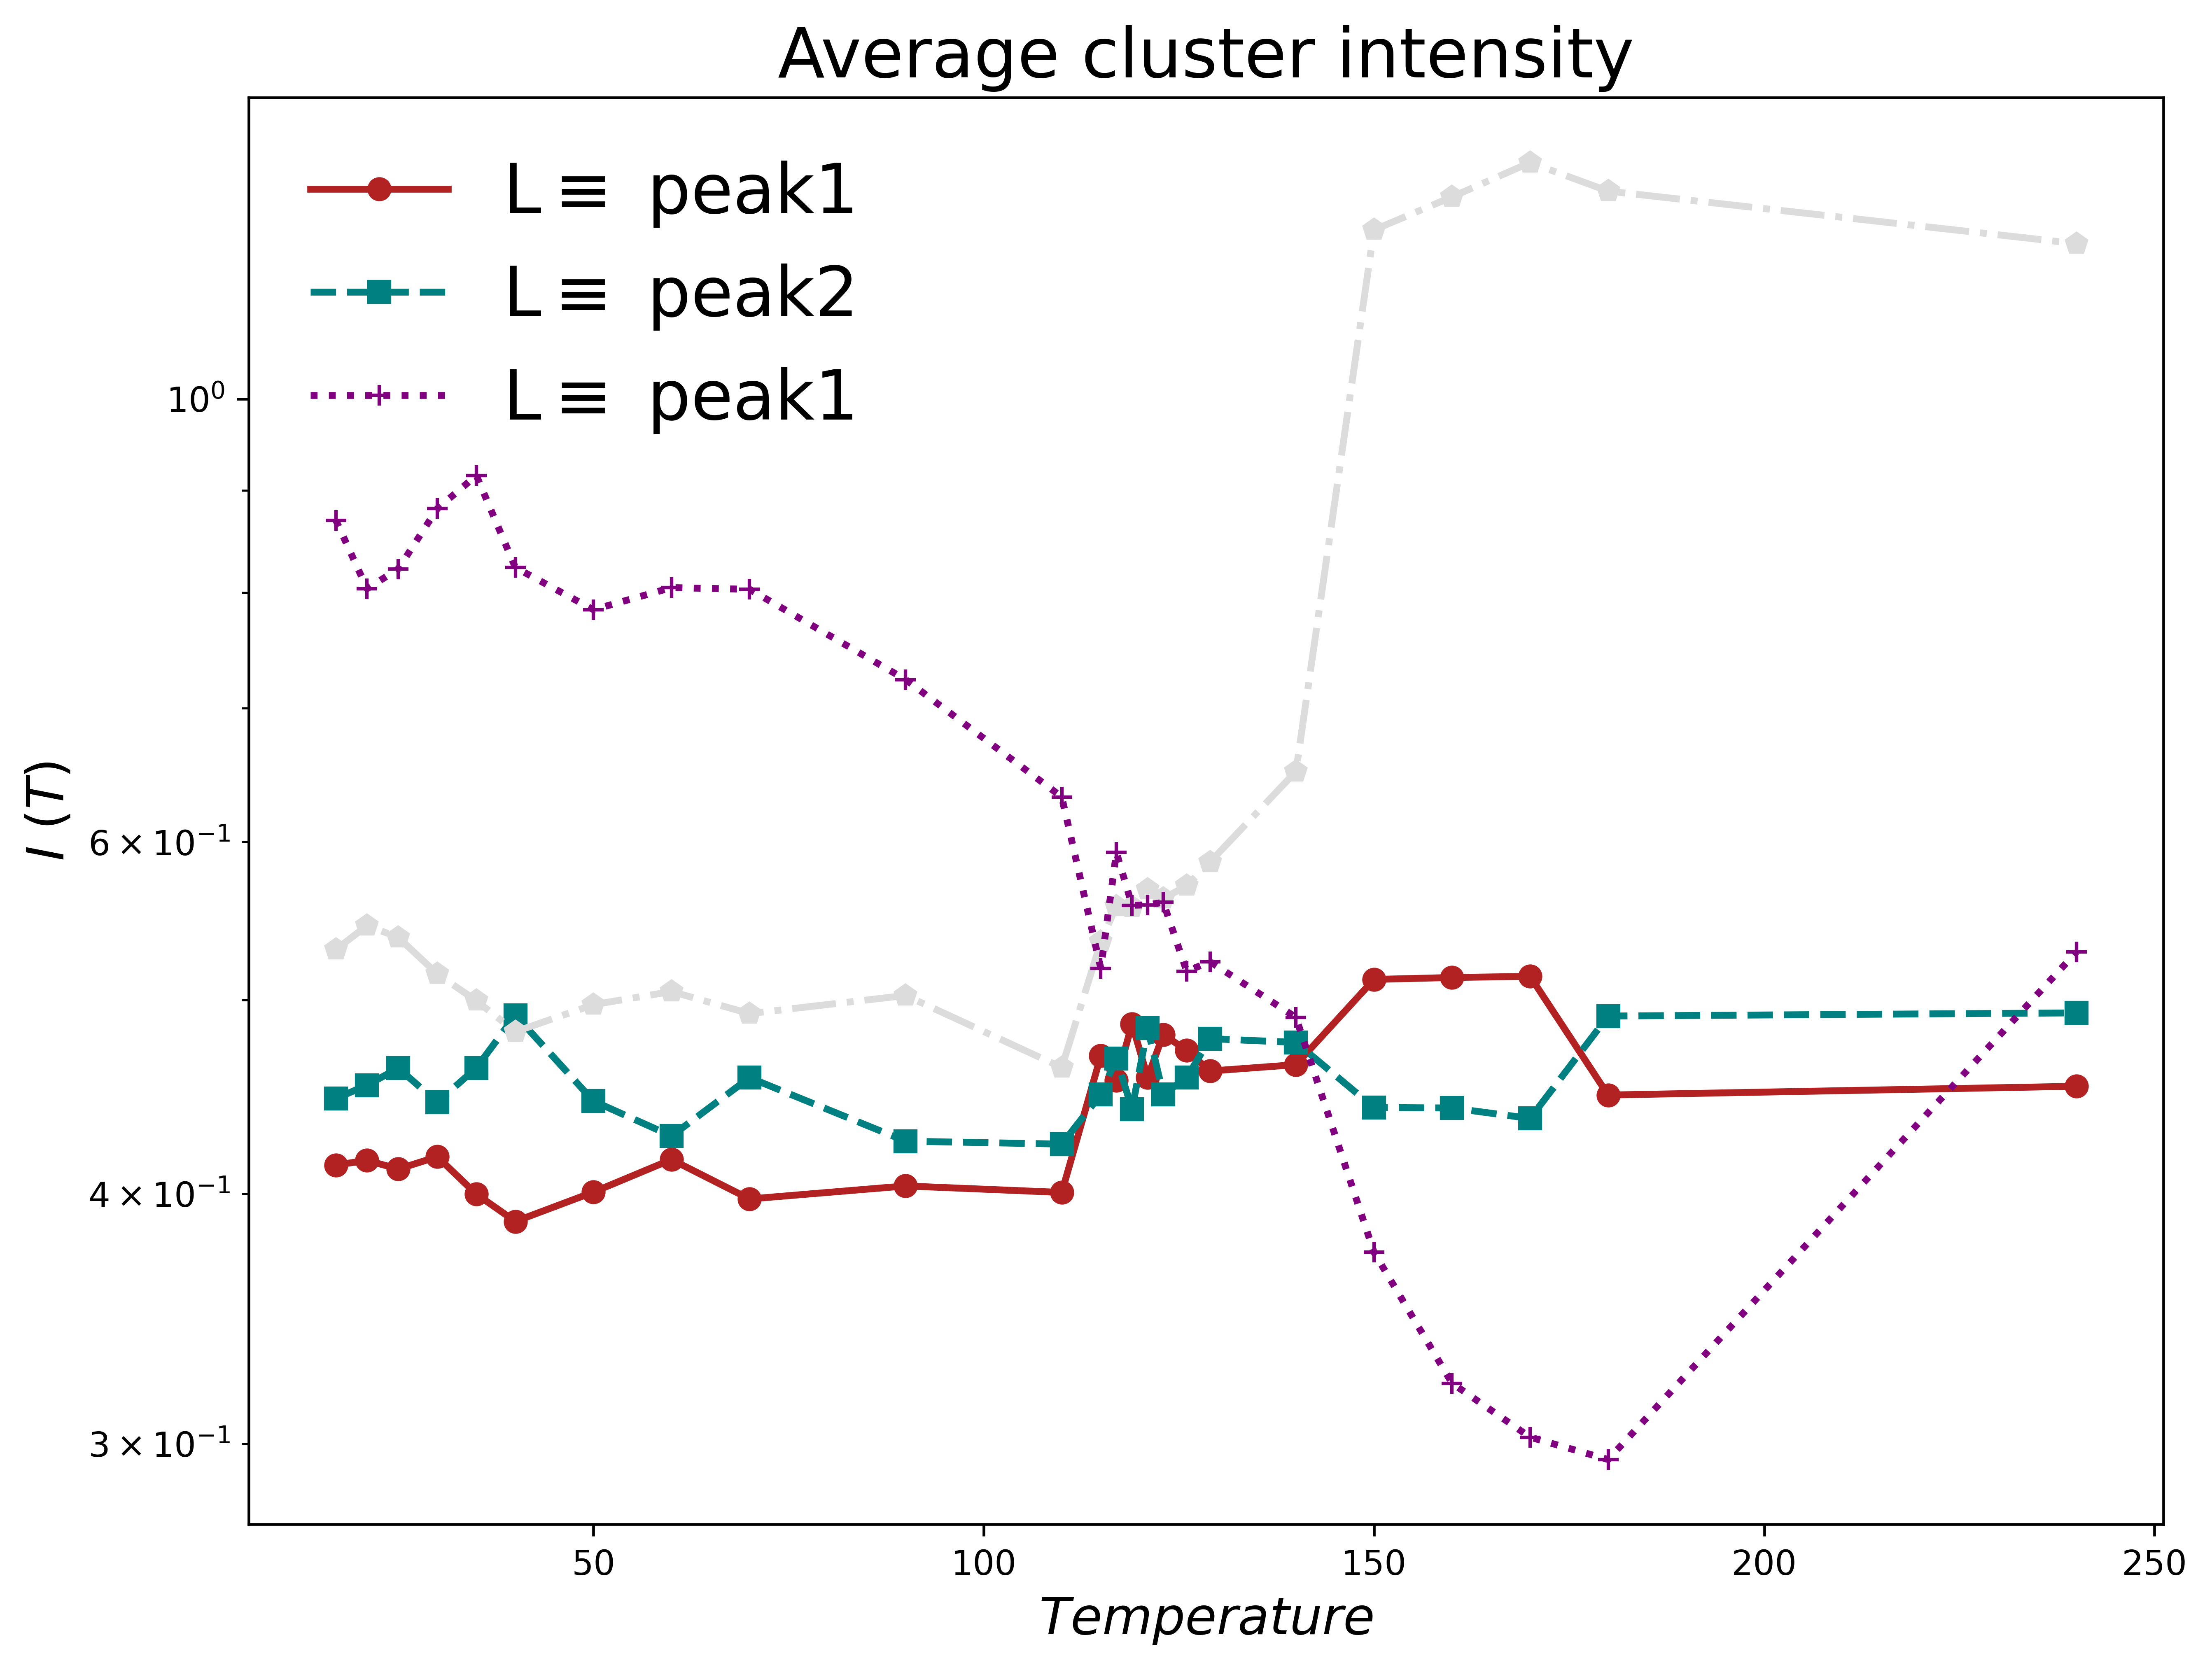

In [68]:
I_cluster_avg=[]


plt.figure(figsize=(10,7.5),dpi=600)
legends=[r'L$\equiv$ peak1',r'L$\equiv$ peak2',None]*5
for i in (range(n_clusters)):

    yc=np.mean(XTEC_D_data[:,cluster_assigns==i],axis=1)
    I_cluster_avg.append(yc)

    plt.plot(Tlist,yc,color=color_list[i], linestyle=line_list[i],marker=marker_list[i],lw=lw_list[i],label=legends[i]);
    
    
plt.xlabel(f'$Temperature $',size=15)
plt.ylabel(r'$I$ ($T$)',size=15)
plt.title(r'Average cluster intensity',size=20)
plt.legend(fontsize=20,frameon=False)
plt.yscale('log')

plt.xticks(size=10);
plt.yticks(size=10);
plt.savefig('Ta2NiSeS70_S1_cluster_4_plot_sig.png')

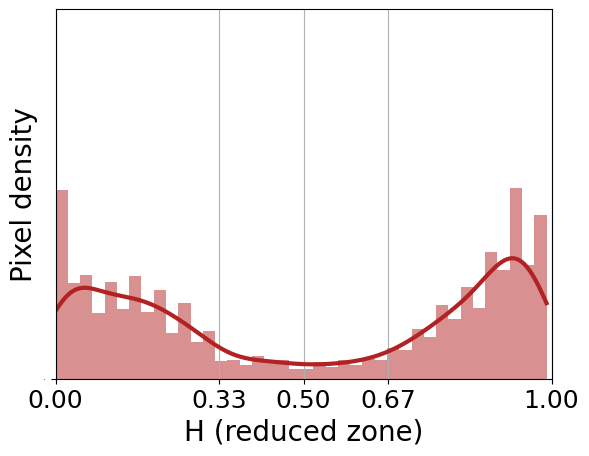

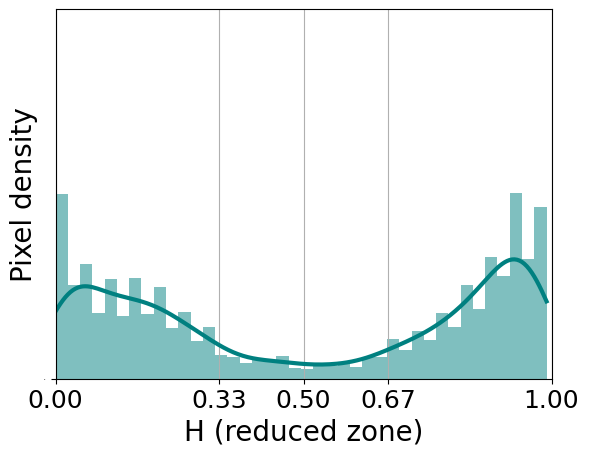

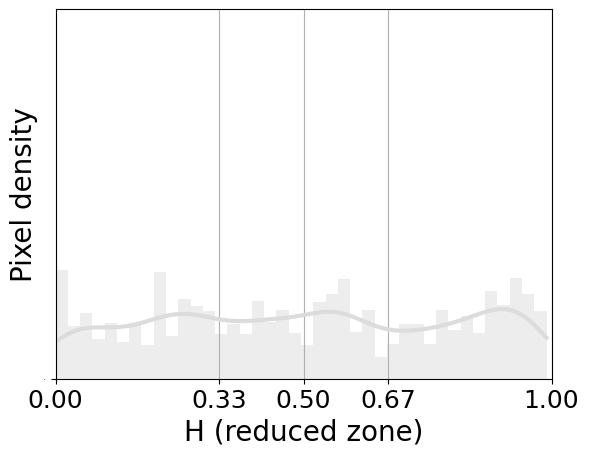

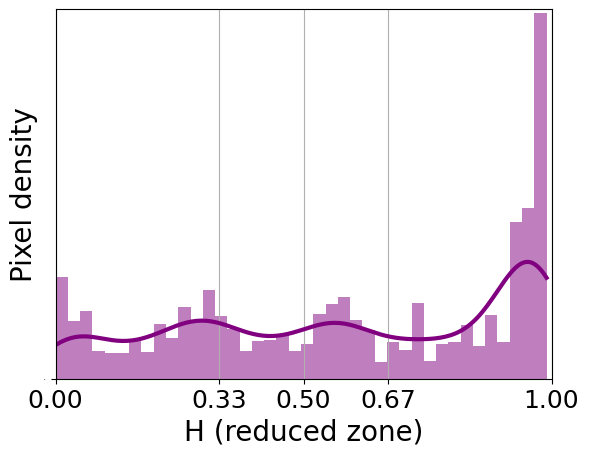

In [69]:
plot_Q_hist(2)